# Problem Description: Predict price of real estate

You are given a dataset with with historical information about real estate valuation. Your job is to build a linear regression model, which can predict the housing valuation based on the estate's attributes.

The dataset can be [found here](https://archive.ics.uci.edu/ml/datasets/Real+estate+valuation+data+set).
</br>
</br>

### Attribute Information

The inputs are as follows</br>
X1=the transaction date (for example, 2013.250=2013 March, 2013.500=2013 June, etc.)</br>
X2=the house age (unit: year)</br>
X3=the distance to the nearest MRT station (unit: meter)</br>
X4=the number of convenience stores in the living circle on foot (integer)</br>
X5=the geographic coordinate, latitude. (unit: degree)</br>
X6=the geographic coordinate, longitude. (unit: degree)</br>
</br>
The output is as follow:</br>
Y= house price of unit area (10000 New Taiwan Dollar/Ping, where Ping is a local unit, 1 Ping = 3.3 meter squared)

## step 1 load data

In [1]:
import pandas as pd

realestate_df = pd.read_excel('Real_estate.xlsx')

realestate_df.tail()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
409,410,2013.000000,13.7,4082.01500,0,24.94155,121.50381,15.4
410,411,2012.666667,5.6,90.45606,9,24.97433,121.54310,50.0
411,412,2013.250000,18.8,390.96960,7,24.97923,121.53986,40.6
412,413,2013.000000,8.1,104.81010,5,24.96674,121.54067,52.5
413,414,2013.500000,6.5,90.45606,9,24.97433,121.54310,63.9


## EDA


In [2]:
realestate_df.describe()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148953,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281995,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.666667,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.916667,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.166667,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.416667,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583333,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


In [3]:
realestate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [5]:
realestate_df.shape

(414, 8)

In [6]:
realestate_df.corr(numeric_only=True)

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
No,1.000000,-0.048634,-0.032808,-0.013573,-0.012699,-0.010110,-0.011059,-0.028587
X1 transaction date,-0.048634,1.000000,0.017542,0.060880,0.009544,0.035016,-0.041065,0.087529
X2 house age,-0.032808,0.017542,1.000000,0.025622,0.049593,0.054420,-0.048520,-0.210567
X3 distance to the nearest MRT station,-0.013573,0.060880,0.025622,1.000000,-0.602519,-0.591067,-0.806317,-0.673613
X4 number of convenience stores,-0.012699,0.009544,0.049593,-0.602519,1.000000,0.444143,0.449099,0.571005
X5 latitude,-0.010110,0.035016,0.054420,-0.591067,0.444143,1.000000,0.412924,0.546307
X6 longitude,-0.011059,-0.041065,-0.048520,-0.806317,0.449099,0.412924,1.000000,0.523287
Y house price of unit area,-0.028587,0.087529,-0.210567,-0.673613,0.571005,0.546307,0.523287,1.000000


In [7]:
cleaned_df = realestate_df.drop(['X1 transaction date','No','X5 latitude', 'X6 longitude'], axis=1)
cleaned_df.head()

,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,Y house price of unit area
0,32.0,84.87882,10,37.9
1,19.5,306.59470,9,42.2
2,13.3,561.98450,5,47.3
3,13.3,561.98450,5,54.8
4,5.0,390.56840,5,43.1


Text(0, 0.5, 'Price')

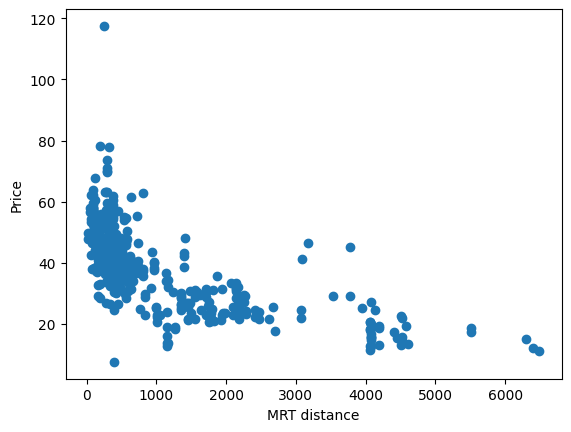

In [8]:
import matplotlib.pyplot as plt

plt.scatter(cleaned_df['X3 distance to the nearest MRT station'], cleaned_df['Y house price of unit area'])
plt.xlabel('MRT distance');
plt.ylabel('Price')

Text(0, 0.5, 'Price')

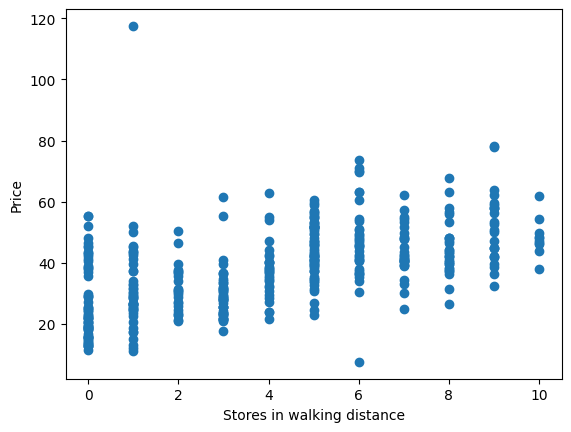

In [10]:
plt.scatter(cleaned_df['X4 number of convenience stores'], cleaned_df['Y house price of unit area'])
plt.xlabel('Stores in walking distance');
plt.ylabel('Price')

Text(0, 0.5, 'Price')

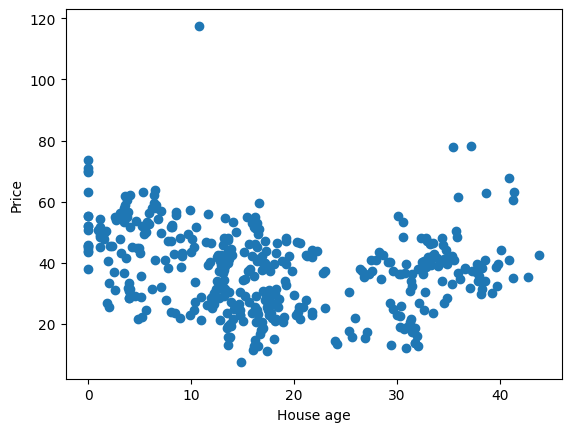

In [11]:
plt.scatter(cleaned_df['X2 house age'], cleaned_df['Y house price of unit area'])
plt.xlabel('House age');
plt.ylabel('Price')

## Train and evaluate a model

In [16]:
from sklearn.model_selection import train_test_split

y = cleaned_df['Y house price of unit area']
X = cleaned_df[['X2 house age', 'X3 distance to the nearest MRT station' ,'X4 number of convenience stores' ]]

#split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [17]:
from sklearn.linear_model import LinearRegression

reg_model = LinearRegression()

reg_model.fit(X_train,y_train)

LinearRegression()

## Test the quality of the model


In [ ]:
y_predicted = reg_model.predict(X_test)


array([49.65029483, 43.63418374, 43.25559711, 40.54504643, 30.02253185,
       42.76115343, 44.05213889, 43.97461726, 28.96883548, 52.53812809,
       32.01140143, 34.41627326, 34.42500748, 28.94187375, 34.10533955,
       32.76928696, 42.76994007, 51.05718419, 31.5997044 , 46.23694741,
        1.60852866, 32.82691283, 46.2087237 , 45.73026011, 16.94793687,
       40.44963146, 16.92441071, 43.25559711, 38.26129413, 35.62242747,
       11.97136777, 37.36257399, 40.39127489, 32.33166396, 44.95567886,
       31.0769121 , 52.71901189, 17.53040182, 45.71069998, 41.24947341,
       33.5998047 , 40.04322085, 47.25263832, 37.83946884, 43.68586483,
       48.15307671, 46.43656126, 25.49063651, 51.73010247, 47.00674875,
       49.65029483, 46.65904428, 39.74781606, 42.97368549, 36.85688572,
       17.50456128, 37.56697735, 34.42301364, 29.94501022, 43.97461726,
       33.33396251, 30.25747554, 17.50456128, 12.10015575,  4.59259481,
       32.85275337, 33.48515031, 46.58254024, 33.10098841, 34.18

In [24]:
from sklearn import metrics
import numpy as np

mse = metrics.mean_squared_error(y_test, y_predicted)
print(f'MSE: {mse}')

print(f'RMSE: {np.sqrt(mse)}')

r2 = reg_model.score(X_test, y_test)

print(f'R2 score: {r2}')


MSE: 58.88825128983575
RMSE: 7.673868078735505
R2 score: 0.6489726933106557
